
===== CSV LOADED =====
    dataset    modelo  n_classes_original      erro
0  dry-bean       EMQ                   7  0.034203
1  dry-bean  EMQ_BCTS                   7  0.033709
2  dry-bean        CC                   7  0.033714
3  dry-bean       PCC                   7  0.033501
4  dry-bean        AC                   7  0.031620

Total original datasets: 24

===== MODELOS RESTANTES =====
['AC', 'CC', 'EMQ', 'EMQ_BCTS', 'FM', 'KDEyCS', 'KDEyHD', 'KDEyML', 'MoSS_CALIBRATED', 'PAC', 'PCC', 'PWK']

Total remaining models: 12

Datasets completos restantes: 24

✅ Todos os datasets possuem todos os modelos restantes.

===== AVERAGE RANK =====
             modelo  rank_dataset
0               PCC      3.833333
1               PWK      4.000000
2   MoSS_CALIBRATED      4.583333
3                CC      5.937500
4            KDEyML      6.041667
5            KDEyHD      6.208333
6            KDEyCS      6.875000
7                AC      7.645833
8               EMQ      7.833333
9          

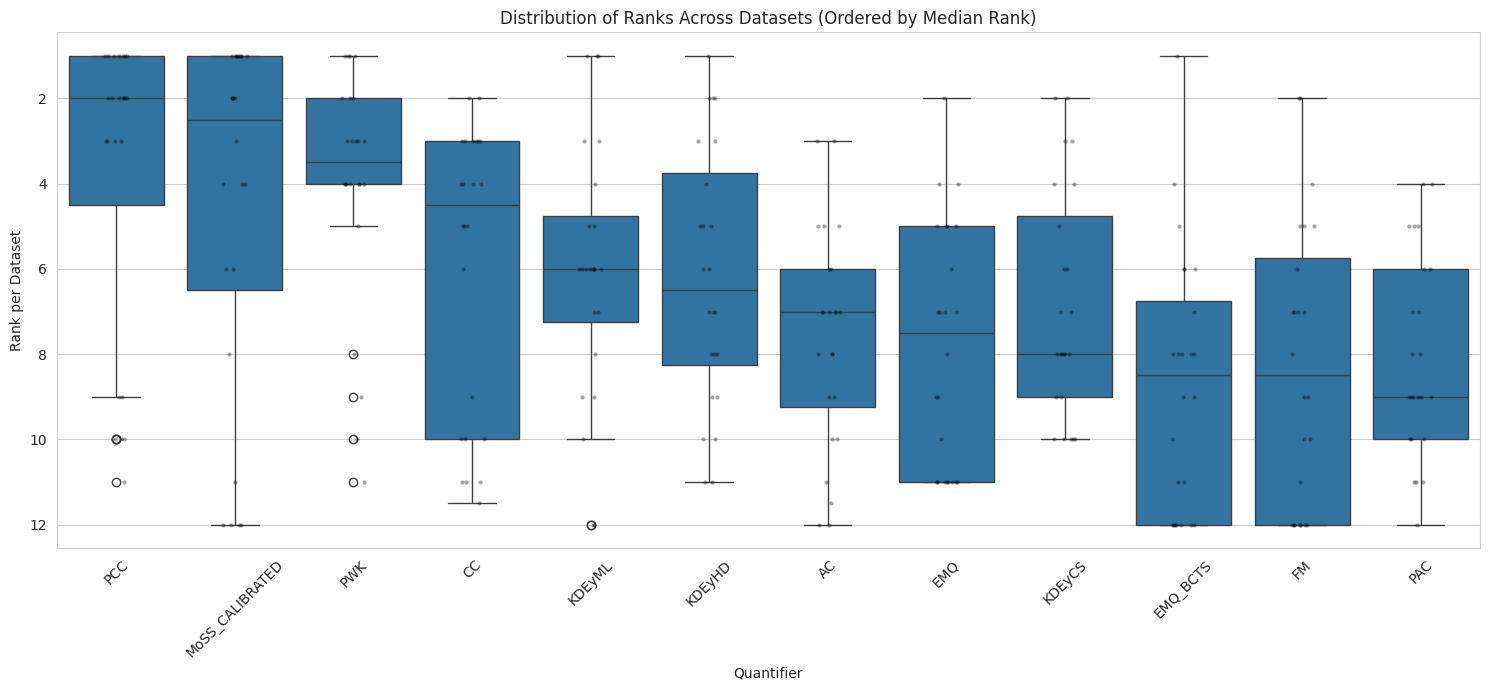

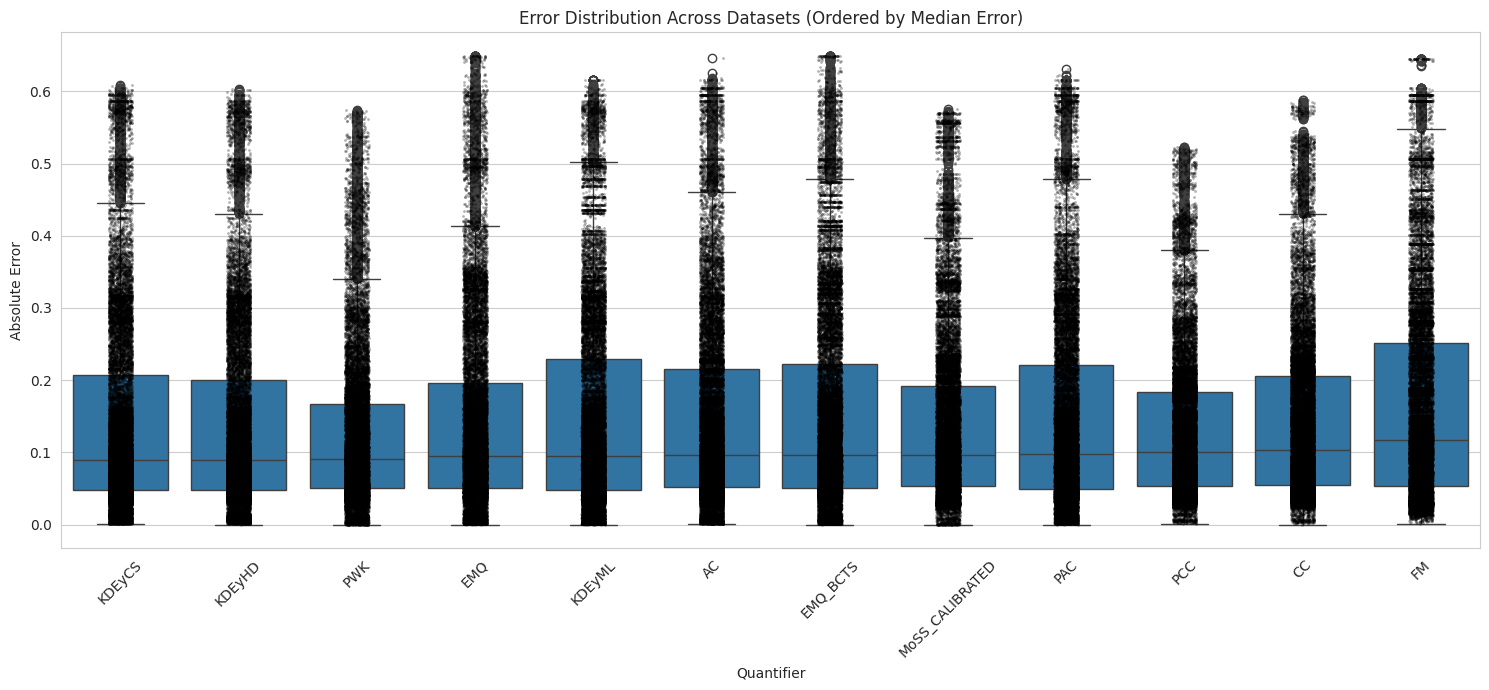


===== GLOBAL MEAN ERROR =====
             modelo  mean_error
0               PWK    0.123571
1               PCC    0.131267
2   MoSS_CALIBRATED    0.137732
3            KDEyHD    0.139621
4            KDEyCS    0.141634
5                CC    0.142910
6               EMQ    0.144195
7               PAC    0.149278
8                AC    0.149691
9            KDEyML    0.149710
10         EMQ_BCTS    0.152198
11               FM    0.167230

===== GLOBAL MEDIAN ERROR =====
             modelo  median_error
0            KDEyCS      0.089066
1            KDEyHD      0.089387
2               PWK      0.090286
3               EMQ      0.094372
4            KDEyML      0.094754
5                AC      0.096669
6          EMQ_BCTS      0.096707
7   MoSS_CALIBRATED      0.096938
8               PAC      0.097896
9               PCC      0.100443
10               CC      0.102955
11               FM      0.116645

===== RESULTS TABLE =====
modelo                                     AC      

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

CSV_PATH = "exp_results.csv"

# ============================================================
# STYLE
# ============================================================

sns.set_style("whitegrid")

# ============================================================
# LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\n===== CSV LOADED =====")
print(df.head())

# ============================================================
# UNIFICAR TODOS OS MOSS
# ============================================================

df["modelo"] = df["modelo"].replace(
    to_replace=r"MoSS_\d+_CALIBRATED",
    value="MoSS_CALIBRATED",
    regex=True
)

# ============================================================
# DATASETS ORIGINAIS
# ============================================================

all_datasets = sorted(df["dataset"].unique())

print(f"\nTotal original datasets: {len(all_datasets)}")

# ============================================================
# REMOVER MODELOS
# ============================================================

modelos_remover = [
    #"KDEyHD",
    #"KDEyCS",
    #"EMQ_BCTS",
    "ClusterQuant"
]

df_filtered = df[
    ~df["modelo"].isin(modelos_remover)
].copy()

# ============================================================
# MODELOS RESTANTES
# ============================================================

remaining_models = sorted(
    df_filtered["modelo"].unique()
)

print("\n===== MODELOS RESTANTES =====")
print(remaining_models)

print(f"\nTotal remaining models: {len(remaining_models)}")

# ============================================================
# GARANTIR DATASETS COMPLETOS
# ============================================================
# Mantém apenas datasets que possuem TODOS os
# modelos restantes
# ============================================================

dataset_model_count = (
    df_filtered.groupby("dataset")["modelo"]
    .nunique()
)

valid_datasets = dataset_model_count[
    dataset_model_count == len(remaining_models)
].index

df = df_filtered[
    df_filtered["dataset"].isin(valid_datasets)
].copy()

print(f"\nDatasets completos restantes: {len(valid_datasets)}")

missing_datasets = set(all_datasets) - set(valid_datasets)

if len(missing_datasets) > 0:
    print("\n⚠️ DATASETS REMOVIDOS (incompletos):")
    for d in sorted(missing_datasets):
        print(d)

# ============================================================
# CHECAGEM FINAL
# ============================================================

final_check = (
    df.groupby("dataset")["modelo"]
    .nunique()
)

assert (final_check == len(remaining_models)).all()

print("\n✅ Todos os datasets possuem todos os modelos restantes.")

# ============================================================
# MÉDIA POR DATASET
# ============================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# ============================================================
# RANK DENTRO DE CADA DATASET
# ============================================================

dataset_mean["rank_dataset"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average")
)

# ============================================================
# AVERAGE RANK FINAL
# ============================================================

avg_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .mean()
    .sort_values()
    .reset_index()
)

print("\n===== AVERAGE RANK =====")
print(avg_rank)

# ============================================================
# SALVAR AVG RANK
# ============================================================

#avg_rank.to_csv(
#    "average_rank_filtered.csv",
#    index=False
#)

# ============================================================
# ORDEM PELA MEDIANA DOS RANKS
# ============================================================

ordem_rank = (
    dataset_mean.groupby("modelo")["rank_dataset"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS RANKS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank
)

sns.stripplot(
    data=dataset_mean,
    x="modelo",
    y="rank_dataset",
    order=ordem_rank,
    color="black",
    alpha=0.35,
    size=3
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Rank per Dataset")

plt.title(
    "Distribution of Ranks Across Datasets "
    "(Ordered by Median Rank)"
)

# rank menor = melhor
plt.gca().invert_yaxis()

plt.tight_layout()

#plt.savefig(
#    "rank_boxplot_filtered.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

# ============================================================
# ORDEM PELA MEDIANA DOS ERROS
# ============================================================

ordem_erro = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .index
)

# ============================================================
# BOXPLOT DOS ERROS
# ============================================================

plt.figure(figsize=(15, 7))

sns.boxplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro
)

sns.stripplot(
    data=df,
    x="modelo",
    y="erro",
    order=ordem_erro,
    color="black",
    alpha=0.30,
    size=2
)

plt.xticks(rotation=45)

plt.xlabel("Quantifier")
plt.ylabel("Absolute Error")

plt.title(
    "Error Distribution Across Datasets "
    "(Ordered by Median Error)"
)

plt.tight_layout()

#plt.savefig(
#    "error_boxplot_filtered.png",
#    dpi=300,
#    bbox_inches="tight"
#)

plt.show()

# ============================================================
# MELHOR MODELO GLOBAL RESTANTE
# ============================================================

global_mean_error = (
    df.groupby("modelo")["erro"]
    .mean()
    .sort_values()
    .reset_index()
)

global_mean_error.columns = [
    "modelo",
    "mean_error"
]

print("\n===== GLOBAL MEAN ERROR =====")
print(global_mean_error)

# ============================================================
# MEDIANA GLOBAL DOS ERROS
# ============================================================

global_median_error = (
    df.groupby("modelo")["erro"]
    .median()
    .sort_values()
    .reset_index()
)

global_median_error.columns = [
    "modelo",
    "median_error"
]

print("\n===== GLOBAL MEDIAN ERROR =====")
print(global_median_error)

# ============================================================
# TABELA FINAL COM NÚMERO DE CLASSES
# ============================================================
# ESTE BLOCO ASSUME QUE EXISTE UMA COLUNA:
#   - "n_classes"
# OU:
#   - "classes"
#
# Se o nome for diferente, apenas troque abaixo.
# ============================================================

N_CLASSES_COLUMN = "n_classes_original"

# média por dataset/modelo
dataset_table = (
    df.groupby(
        ["dataset", N_CLASSES_COLUMN, "modelo"]
    )["erro"]
    .mean()
    .reset_index()
)

# pivot table
results_table = dataset_table.pivot_table(
    index=["dataset", N_CLASSES_COLUMN],
    columns="modelo",
    values="erro"
)

# ordenar datasets pelo número de classes
results_table = results_table.sort_index(level=1)

# arredondar
results_table = results_table.round(6)

print("\n===== RESULTS TABLE =====")
print(results_table)

# salvar csv
results_table.to_csv(
    "results_by_dataset_and_classes.csv"
)

# ============================================================
# TABELA COM RANKS POR DATASET
# ============================================================

rank_table = (
    dataset_mean.pivot_table(
        index="dataset",
        columns="modelo",
        values="rank_dataset"
    )
    .round(3)
)

print("\n===== RANK TABLE =====")
print(rank_table)

#rank_table.to_csv(
#    "rank_table_per_dataset.csv"
#)

# ============================================================
# RESUMO FINAL
# ============================================================

print("\n✅ ANALYSIS FINISHED")

print("\nArquivos gerados:")

print(" - average_rank_filtered.csv")
print(" - global_mean_error_filtered.csv")
print(" - global_median_error_filtered.csv")

print(" - results_by_dataset_and_classes.csv")
print(" - rank_table_per_dataset.csv")

print(" - rank_boxplot_filtered.png")
print(" - error_boxplot_filtered.png")